### Pipeline Transformasi Geometrik Untuk Aplikasi Registrasi Citra
Muhammad Rafi Fatihul Ihsan (24343016)

Import Modul

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import time
import warnings
import os

warnings.filterwarnings('ignore')

Path Gambar dan Resize

In [2]:
REF_IMAGE_PATH = r"C:\Users\Pongo\Desktop\kuliah\Semester 4\Pengolahan Citra Digital\minggu 3\program\src\img\botol_sample_tegak.jpeg"
MOVING_IMAGE_PATH = r"C:\Users\Pongo\Desktop\kuliah\Semester 4\Pengolahan Citra Digital\minggu 3\program\src\img\botol_sample_miring.jpeg"
IMAGE_SIZE = 500

Fungsi Load Images

In [3]:
def load_images(ref_path, moving_path, size=500):
    """Load 2 images dengan perspektif berbeda"""
    
    print(f"\n[LOADING IMAGE 1] REFERENCE IMAGE (LURUS)")
    print("-" * 60)
    
    if not os.path.exists(ref_path):
        raise FileNotFoundError(f"Reference image not found: {ref_path}")
    
    print(f"✓ Path ditemukan: {ref_path}")
    ref_img = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)
    
    if ref_img is None:
        raise ValueError(f"Failed to read reference image")
    
    ref_img = cv2.resize(ref_img, (size, size), interpolation=cv2.INTER_AREA)
    print(f"✓ Gambar referensi berhasil dimuat: {size}x{size} pixel")
    
    print(f"\n[LOADING IMAGE 2] MOVING IMAGE (MIRING/PERSPEKTIF BERBEDA)")
    print("-" * 60)
    
    if not os.path.exists(moving_path):
        raise FileNotFoundError(f"Moving image not found: {moving_path}")
    
    print(f"✓ Path ditemukan: {moving_path}")
    moving_img = cv2.imread(moving_path, cv2.IMREAD_GRAYSCALE)
    
    if moving_img is None:
        raise ValueError(f"Failed to read moving image")
    
    moving_img = cv2.resize(moving_img, (size, size), interpolation=cv2.INTER_AREA)
    print(f"✓ Gambar moving berhasil dimuat: {size}x{size} pixel")
    
    return ref_img, moving_img

Fungsi Transformasi Dasar (Translasi, Rotasi, Scaling)

In [4]:
def apply_translation(img, tx, ty):
    """Translasi: menggeser gambar (tx, ty) pixel
    Menggunakan matriks: M = [[1, 0, tx], [0, 1, ty]]
    """
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M_trans, (img.shape[1], img.shape[0]))


def apply_rotation(img, angle, center=None):
    """Rotasi: merotasi gambar dengan sudut (degrees)
    Menggunakan matriks rotasi 2D
    """
    if center is None:
        center = (img.shape[1]//2, img.shape[0]//2)
    M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M_rot, (img.shape[1], img.shape[0]))


def apply_scaling(img, scale_x, scale_y):
    """Scaling: memperbesar/memperkecil gambar
    Menggunakan matriks: M = [[scale_x, 0, 0], [0, scale_y, 0]]
    """
    M_scale = np.float32([[scale_x, 0, 0], [0, scale_y, 0]])
    new_size = (int(img.shape[1]*scale_x), int(img.shape[0]*scale_y))
    return cv2.warpAffine(img, M_scale, new_size)

Fungsi Metrik Evaluasi (MSE, PSNR, SSIM, MAE)

In [6]:
def calculate_mse(img_ref, img_target):
    """Mean Squared Error - mengukur rata-rata kuadrat perbedaan pixel"""
    return np.mean((img_ref.astype(float) - img_target.astype(float))**2)


def calculate_psnr(img_ref, img_target, max_pixel=255):
    """Peak Signal-to-Noise Ratio (dB) - mengukur kualitas rekonstruksi"""
    mse = calculate_mse(img_ref, img_target)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_pixel**2) / mse)


def calculate_mae(img_ref, img_target):
    """Mean Absolute Error - rata-rata absolute perbedaan pixel"""
    return np.mean(np.abs(img_ref.astype(float) - img_target.astype(float)))


def calculate_ssim(img_ref, img_target, window_size=11):
    """Structural Similarity Index - mengukur kemiripan struktural"""
    if img_ref.shape != img_target.shape:
        img_target = cv2.resize(img_target, (img_ref.shape[1], img_ref.shape[0]))
    
    img_ref = img_ref.astype(np.float32)
    img_target = img_target.astype(np.float32)
    
    C1, C2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    
    mu1 = cv2.blur(img_ref, (window_size, window_size))
    mu2 = cv2.blur(img_target, (window_size, window_size))
    
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2
    
    sigma1_sq = cv2.blur(img_ref ** 2, (window_size, window_size)) - mu1_sq
    sigma2_sq = cv2.blur(img_target ** 2, (window_size, window_size)) - mu2_sq
    sigma12 = cv2.blur(img_ref * img_target, (window_size, window_size)) - mu1_mu2
    
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    
    return np.mean(ssim_map)


def calculate_all_metrics(img_ref, img_target):
    """Hitung semua metrik sekaligus"""
    mse = calculate_mse(img_ref, img_target)
    psnr = calculate_psnr(img_ref, img_target)
    mae = calculate_mae(img_ref, img_target)
    ssim = calculate_ssim(img_ref, img_target)
    return {'mse': mse, 'psnr': psnr, 'mae': mae, 'ssim': ssim}

Load Images

In [7]:
print(f"\n" + "="*80)
print("LANGKAH 1: LOAD DUA GAMBAR INPUT")
print("="*80)

try:
    ref_img, moving_img = load_images(REF_IMAGE_PATH, MOVING_IMAGE_PATH, IMAGE_SIZE)
    h, w = ref_img.shape
    print(f"\n✓ Dimensi gambar: {w}x{h} pixel")
except Exception as e:
    print(f"\n✗ ERROR: {e}")
    raise


LANGKAH 1: LOAD DUA GAMBAR INPUT

[LOADING IMAGE 1] REFERENCE IMAGE (LURUS)
------------------------------------------------------------
✓ Path ditemukan: C:\Users\Pongo\Desktop\kuliah\Semester 4\Pengolahan Citra Digital\minggu 3\program\src\img\botol_sample_tegak.jpeg
✓ Gambar referensi berhasil dimuat: 500x500 pixel

[LOADING IMAGE 2] MOVING IMAGE (MIRING/PERSPEKTIF BERBEDA)
------------------------------------------------------------
✓ Path ditemukan: C:\Users\Pongo\Desktop\kuliah\Semester 4\Pengolahan Citra Digital\minggu 3\program\src\img\botol_sample_miring.jpeg
✓ Gambar moving berhasil dimuat: 500x500 pixel

✓ Dimensi gambar: 500x500 pixel


Visualisasi Input Images (Gambar 1)

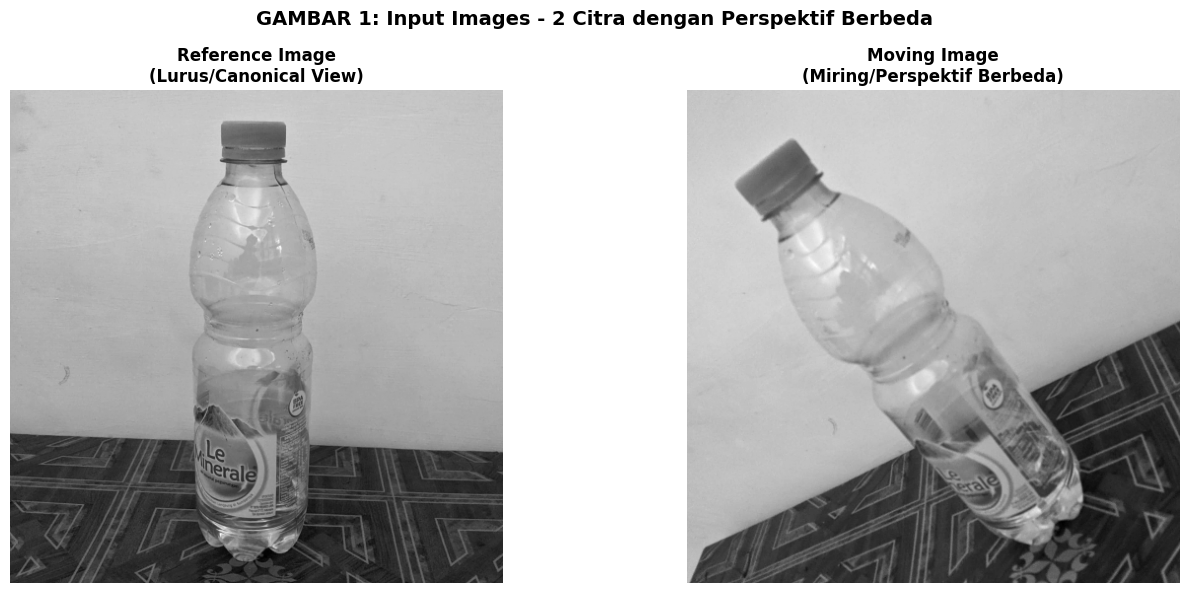

In [10]:
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
axes1[0].imshow(ref_img, cmap='gray')
axes1[0].set_title('Reference Image\n(Lurus/Canonical View)', fontweight='bold', fontsize=12)
axes1[0].axis('off')

axes1[1].imshow(moving_img, cmap='gray')
axes1[1].set_title('Moving Image\n(Miring/Perspektif Berbeda)', fontweight='bold', fontsize=12)
axes1[1].axis('off')

fig1.suptitle('GAMBAR 1: Input Images - 2 Citra dengan Perspektif Berbeda', 
              fontsize=14, fontweight='bold', y=0.98)
fig1.tight_layout()
plt.show()

Transformasi Dasar (Translasi, Rotasi, Scaling)

In [11]:
print(f"" + "="*80)
print("LANGKAH 2: TRANSFORMASI DASAR (TRANSLASI, ROTASI, SCALING)")
print("="*80)

print(f"\n[TRANSLASI] tx=30, ty=40")
print(f"  Matriks: M_trans = [[1, 0, 30], [0, 1, 40]]")
img_trans = apply_translation(ref_img, tx=30, ty=40)
print(f"✓ Translasi selesai - gambar digeser 30 pixel ke kanan, 40 pixel ke bawah")

print(f"\n[ROTASI] angle=15 derajat")
print(f"  Menggunakan cv2.getRotationMatrix2D(center, 15, scale=1.0)")
img_rot = apply_rotation(ref_img, angle=15)
print(f"✓ Rotasi selesai - gambar dirotasi 15 derajat dari pusat")

print(f"\n[SCALING] scale=1.2x")
print(f"  Matriks: M_scale = [[1.2, 0, 0], [0, 1.2, 0]]")
img_scale = apply_scaling(ref_img, scale_x=1.2, scale_y=1.2)
print(f"✓ Scaling selesai - gambar diperbesar 1.2x (ukuran baru: {img_scale.shape})")

LANGKAH 2: TRANSFORMASI DASAR (TRANSLASI, ROTASI, SCALING)

[TRANSLASI] tx=30, ty=40
  Matriks: M_trans = [[1, 0, 30], [0, 1, 40]]
✓ Translasi selesai - gambar digeser 30 pixel ke kanan, 40 pixel ke bawah

[ROTASI] angle=15 derajat
  Menggunakan cv2.getRotationMatrix2D(center, 15, scale=1.0)
✓ Rotasi selesai - gambar dirotasi 15 derajat dari pusat

[SCALING] scale=1.2x
  Matriks: M_scale = [[1.2, 0, 0], [0, 1.2, 0]]
✓ Scaling selesai - gambar diperbesar 1.2x (ukuran baru: (600, 600))


Visualisasi Transformasi Dasar (Gambar 2)

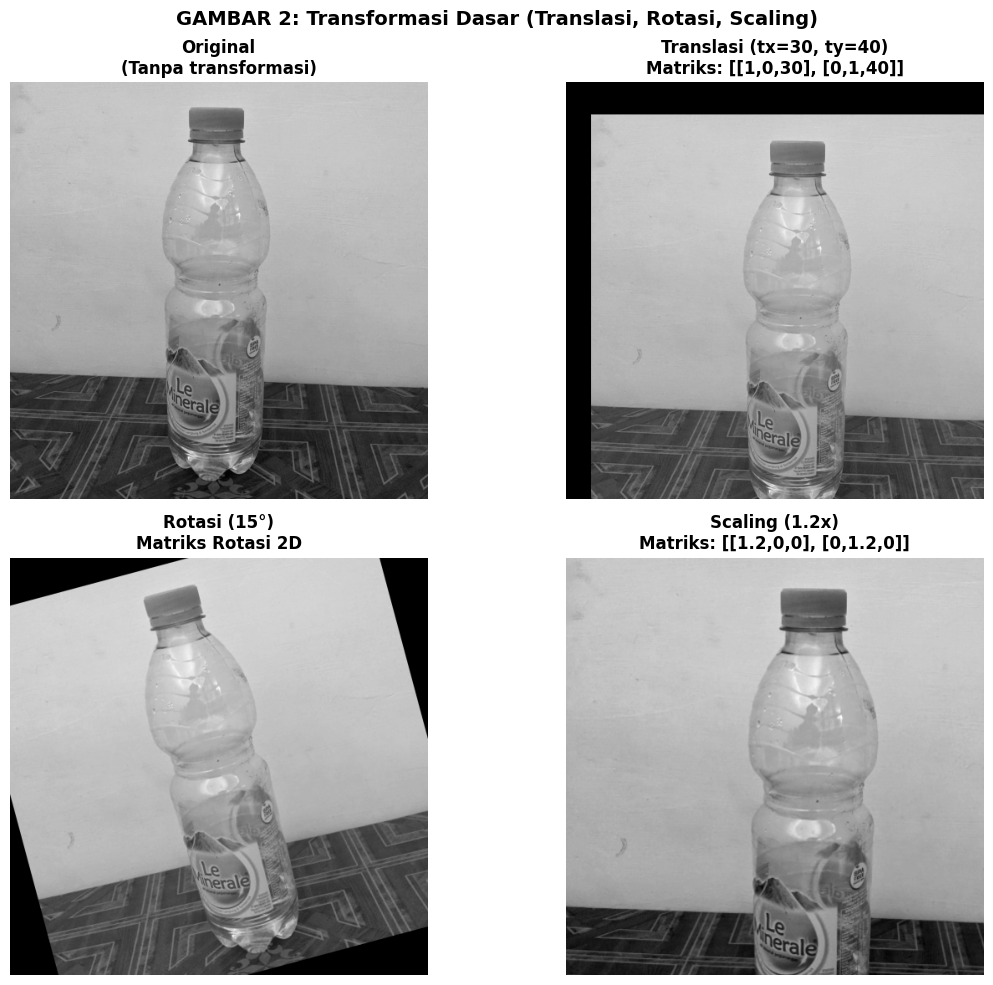

In [12]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))

axes2[0, 0].imshow(ref_img, cmap='gray')
axes2[0, 0].set_title('Original\n(Tanpa transformasi)', fontweight='bold')
axes2[0, 0].axis('off')

axes2[0, 1].imshow(img_trans, cmap='gray')
axes2[0, 1].set_title('Translasi (tx=30, ty=40)\nMatriks: [[1,0,30], [0,1,40]]', fontweight='bold')
axes2[0, 1].axis('off')

axes2[1, 0].imshow(img_rot, cmap='gray')
axes2[1, 0].set_title('Rotasi (15°)\nMatriks Rotasi 2D', fontweight='bold')
axes2[1, 0].axis('off')

axes2[1, 1].imshow(img_scale[:IMAGE_SIZE, :IMAGE_SIZE], cmap='gray')
axes2[1, 1].set_title('Scaling (1.2x)\nMatriks: [[1.2,0,0], [0,1.2,0]]', fontweight='bold')
axes2[1, 1].axis('off')

fig2.suptitle('GAMBAR 2: Transformasi Dasar (Translasi, Rotasi, Scaling)', 
              fontsize=14, fontweight='bold', y=0.98)
fig2.tight_layout()
plt.show()

Perspektif Transformation (4 Titik)

In [13]:
print(f"" + "="*80)
print("LANGKAH 3: ESTIMASI TRANSFORMASI PERSPEKTIF (4 TITIK)")
print("="*80)

# 4 titik sudut citra original
pts_original = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
# 4 titik setelah distorsi perspektif
pts_tilted = np.float32([[50, 60], [w-30, 40], [w-80, h-50], [30, h-20]])

print(f"\n[PERSPEKTIF POINTS - 4 Titik Sudut]")
print(f"  Original points (citra asli):")
for i, pt in enumerate(pts_original):
    print(f"    P{i+1}: {pt}")
print(f"  Tilted points (citra setelah distorsi):")
for i, pt in enumerate(pts_tilted):
    print(f"    P'{i+1}: {pt}")

# Estimasi homography matrix dari 4 titik
H_persp = cv2.getPerspectiveTransform(pts_original, pts_tilted)
moving_img_persp = cv2.warpPerspective(ref_img, H_persp, (w, h), borderValue=255)
print(f"\n✓ Perspektif transformation dari 4 titik selesai")
print(f"  Menggunakan: cv2.getPerspectiveTransform(pts_original, pts_tilted)")

metrics_persp_base = calculate_all_metrics(ref_img, moving_img_persp)
print(f"\n[PERSPEKTIF TRANSFORMATION QUALITY]")
print(f"  MSE: {metrics_persp_base['mse']:.2f}")
print(f"  PSNR: {metrics_persp_base['psnr']:.2f} dB")
print(f"  SSIM: {metrics_persp_base['ssim']:.4f}")

LANGKAH 3: ESTIMASI TRANSFORMASI PERSPEKTIF (4 TITIK)

[PERSPEKTIF POINTS - 4 Titik Sudut]
  Original points (citra asli):
    P1: [0. 0.]
    P2: [500.   0.]
    P3: [500. 500.]
    P4: [  0. 500.]
  Tilted points (citra setelah distorsi):
    P'1: [50. 60.]
    P'2: [470.  40.]
    P'3: [420. 450.]
    P'4: [ 30. 480.]

✓ Perspektif transformation dari 4 titik selesai
  Menggunakan: cv2.getPerspectiveTransform(pts_original, pts_tilted)

[PERSPEKTIF TRANSFORMATION QUALITY]
  MSE: 7216.42
  PSNR: 9.55 dB
  SSIM: 0.5878


Affine Transformation (3 Titik)

In [14]:
print(f"\n" + "="*80)
print("LANGKAH 4: ESTIMASI TRANSFORMASI AFFINE (3 TITIK)")
print("="*80)

# 3 titik untuk affine transformation
pts_affine_src = np.float32([[0, 0], [w, 0], [w//2, h]])
pts_affine_dst = np.float32([[50, 60], [w-30, 40], [w//2-20, h-50]])

print(f"\n[AFFINE POINTS - 3 Titik]")
print(f"  Source points (citra asli):")
for i, pt in enumerate(pts_affine_src):
    print(f"    P{i+1}: {pt}")
print(f"  Destination points (titik tujuan):")
for i, pt in enumerate(pts_affine_dst):
    print(f"    P'{i+1}: {pt}")

# Estimasi affine matrix dari 3 titik
M_affine = cv2.getAffineTransform(pts_affine_src, pts_affine_dst)
moving_img_affine = cv2.warpAffine(ref_img, M_affine, (w, h), borderValue=255)
print(f"\n✓ Affine transformation dari 3 titik selesai")
print(f"  Menggunakan: cv2.getAffineTransform(pts_src, pts_dst)")

metrics_affine_base = calculate_all_metrics(ref_img, moving_img_affine)
print(f"\n[AFFINE TRANSFORMATION QUALITY]")
print(f"  MSE: {metrics_affine_base['mse']:.2f}")
print(f"  PSNR: {metrics_affine_base['psnr']:.2f} dB")
print(f"  SSIM: {metrics_affine_base['ssim']:.4f}")


LANGKAH 4: ESTIMASI TRANSFORMASI AFFINE (3 TITIK)

[AFFINE POINTS - 3 Titik]
  Source points (citra asli):
    P1: [0. 0.]
    P2: [500.   0.]
    P3: [250. 500.]
  Destination points (titik tujuan):
    P'1: [50. 60.]
    P'2: [470.  40.]
    P'3: [230. 450.]

✓ Affine transformation dari 3 titik selesai
  Menggunakan: cv2.getAffineTransform(pts_src, pts_dst)

[AFFINE TRANSFORMATION QUALITY]
  MSE: 7559.33
  PSNR: 9.35 dB
  SSIM: 0.5755


Visualisasi Affine vs Perspektif (Gambar 3)

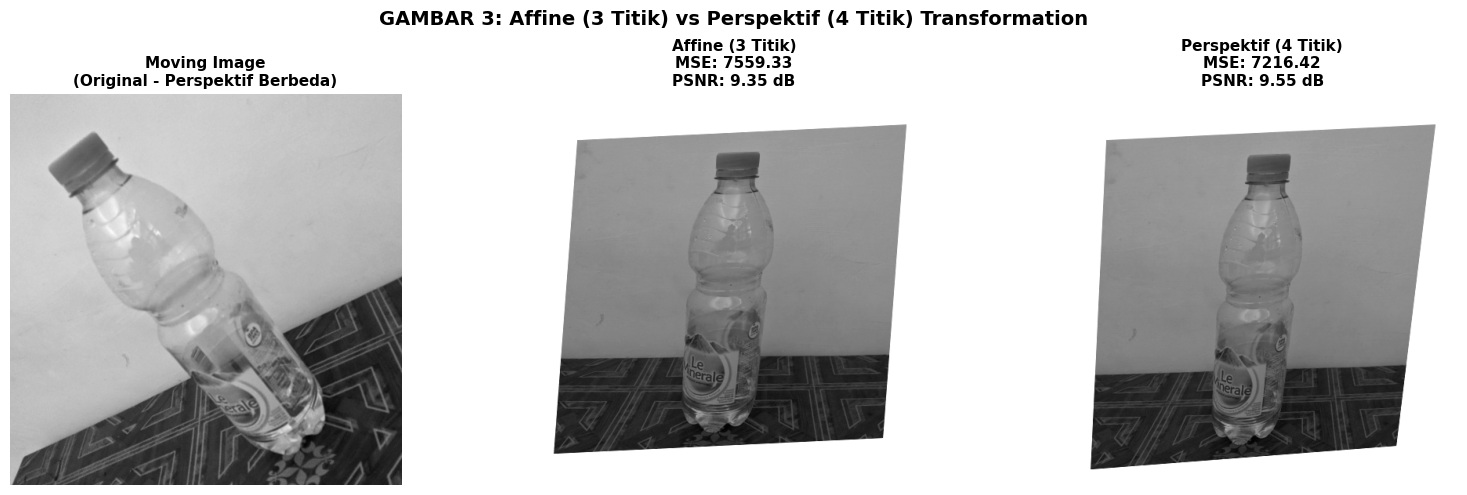

In [15]:
fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))

axes3[0].imshow(moving_img, cmap='gray')
axes3[0].set_title('Moving Image\n(Original - Perspektif Berbeda)', fontweight='bold', fontsize=11)
axes3[0].axis('off')

axes3[1].imshow(moving_img_affine, cmap='gray')
axes3[1].set_title(f'Affine (3 Titik)\nMSE: {metrics_affine_base["mse"]:.2f}\nPSNR: {metrics_affine_base["psnr"]:.2f} dB', 
                  fontweight='bold', fontsize=11)
axes3[1].axis('off')

axes3[2].imshow(moving_img_persp, cmap='gray')
axes3[2].set_title(f'Perspektif (4 Titik)\nMSE: {metrics_persp_base["mse"]:.2f}\nPSNR: {metrics_persp_base["psnr"]:.2f} dB', 
                  fontweight='bold', fontsize=11)
axes3[2].axis('off')

fig3.suptitle('GAMBAR 3: Affine (3 Titik) vs Perspektif (4 Titik) Transformation', 
              fontsize=14, fontweight='bold', y=0.98)
fig3.tight_layout()
plt.show()

Evaluasi Interpolasi

In [16]:
print(f"" + "="*80)
print("LANGKAH 5: EVALUASI METODE INTERPOLASI (3 METODE)")
print("="*80)

methods = {
    'Nearest': cv2.INTER_NEAREST,
    'Bilinear': cv2.INTER_LINEAR,
    'Bicubic': cv2.INTER_CUBIC
}

print(f"\nMengevaluasi 3 metode interpolasi pada perspektif transformation:")
print(f"\n{'Metode':<15} {'Waktu (ms)':<12} {'MSE':<12} {'PSNR (dB)':<12} {'SSIM':<12}")
print("-" * 63)

results_interp = {}
for name, flag in methods.items():
    start_time = time.time()
    restored = cv2.warpPerspective(moving_img_persp, H_persp, (w, h), flags=flag, borderValue=255)
    end_time = time.time()
    
    waktu = (end_time - start_time) * 1000
    metrics = calculate_all_metrics(ref_img, restored)
    
    results_interp[name] = {
        'img': restored,
        'mse': metrics['mse'],
        'psnr': metrics['psnr'],
        'ssim': metrics['ssim'],
        'time_ms': waktu
    }
    
    print(f"{name:<15} {waktu:>10.3f}   {metrics['mse']:>10.2f}   {metrics['psnr']:>10.2f}   {metrics['ssim']:>10.4f}")

LANGKAH 5: EVALUASI METODE INTERPOLASI (3 METODE)

Mengevaluasi 3 metode interpolasi pada perspektif transformation:

Metode          Waktu (ms)   MSE          PSNR (dB)    SSIM        
---------------------------------------------------------------
Nearest              0.570     11502.44         7.52       0.5708
Bilinear             0.565     11487.13         7.53       0.5737
Bicubic              0.813     11494.04         7.53       0.5709


Visualisasi Interpolasi

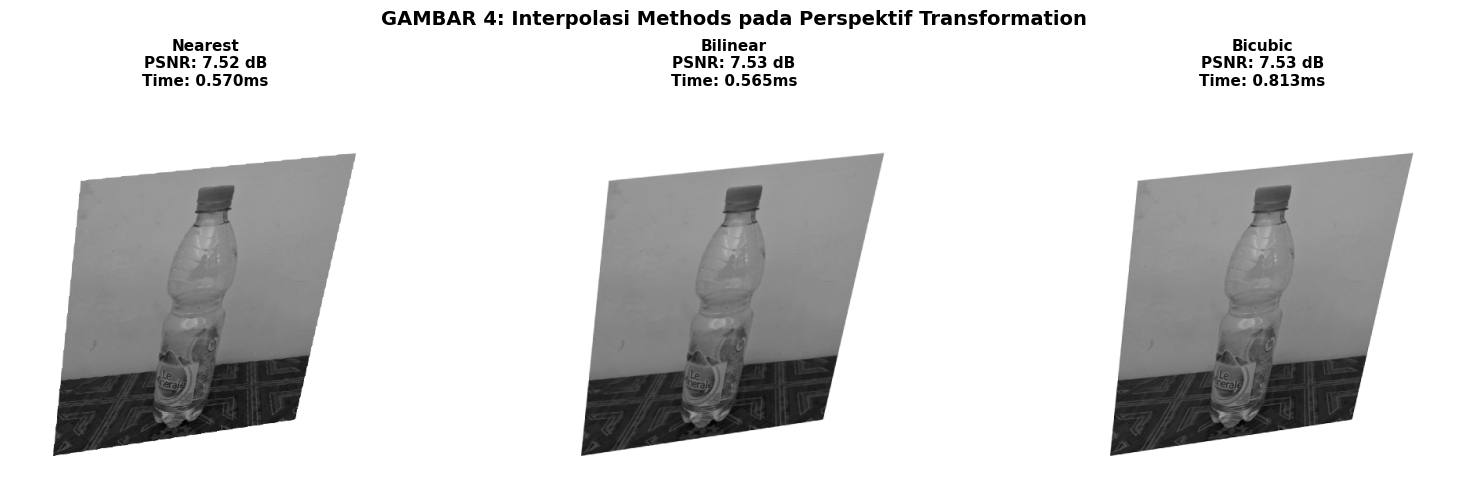

In [17]:
fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, data) in enumerate(results_interp.items()):
    axes4[idx].imshow(data['img'], cmap='gray')
    title = (f"{name}\n" f"PSNR: {data['psnr']:.2f} dB\n" f"Time: {data['time_ms']:.3f}ms")
    axes4[idx].set_title(title, fontweight='bold', fontsize=11)
    axes4[idx].axis('off')

fig4.suptitle('GAMBAR 4: Interpolasi Methods pada Perspektif Transformation', 
              fontsize=14, fontweight='bold', y=0.98)
fig4.tight_layout()
plt.show()

Perbandingan Metrik Interpolasi

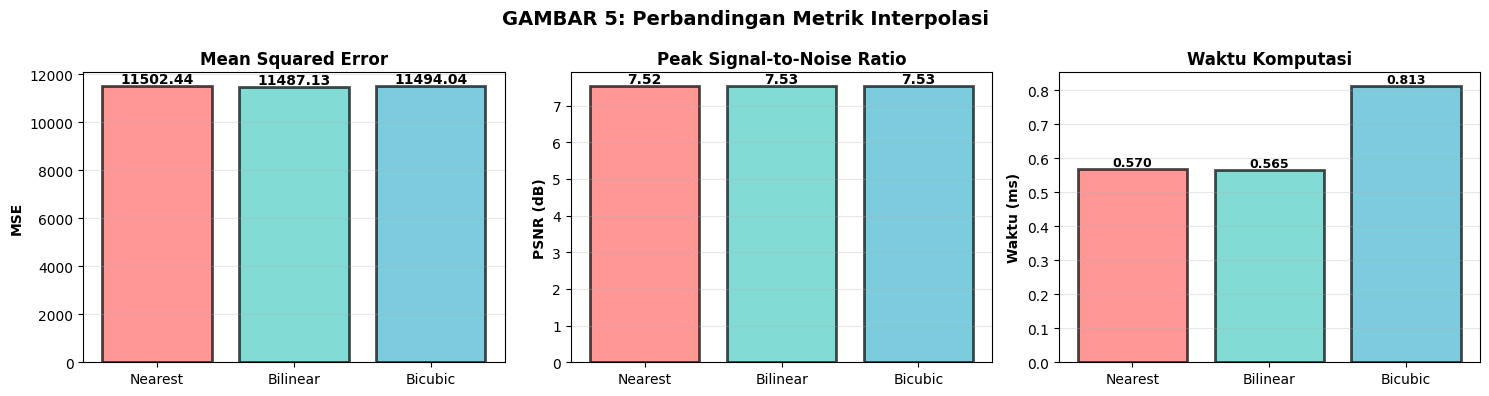

In [18]:
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 4))

methods_names = list(results_interp.keys())
mse_vals = [results_interp[m]['mse'] for m in methods_names]
psnr_vals = [results_interp[m]['psnr'] for m in methods_names]
time_vals = [results_interp[m]['time_ms'] for m in methods_names]

# MSE
bars = axes5[0].bar(methods_names, mse_vals, 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                    alpha=0.7, edgecolor='black', linewidth=2)
axes5[0].set_ylabel('MSE', fontweight='bold')
axes5[0].set_title('Mean Squared Error', fontweight='bold')
axes5[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mse_vals):
    axes5[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# PSNR
bars = axes5[1].bar(methods_names, psnr_vals, 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                    alpha=0.7, edgecolor='black', linewidth=2)
axes5[1].set_ylabel('PSNR (dB)', fontweight='bold')
axes5[1].set_title('Peak Signal-to-Noise Ratio', fontweight='bold')
axes5[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, psnr_vals):
    axes5[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# WAKTU
bars = axes5[2].bar(methods_names, time_vals, 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                    alpha=0.7, edgecolor='black', linewidth=2)
axes5[2].set_ylabel('Waktu (ms)', fontweight='bold')
axes5[2].set_title('Waktu Komputasi', fontweight='bold')
axes5[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, time_vals):
    axes5[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

fig5.suptitle('GAMBAR 5: Perbandingan Metrik Interpolasi', 
              fontsize=14, fontweight='bold', y=0.98)
fig5.tight_layout()
plt.show()

Hasil Analisis dan Rekomendasi

In [20]:
print(f"\n" + "="*80)
print("ANALISIS MENDALAM & REKOMENDASI")
print("="*80)

print(f"\n[INFO UMUM]")
print(f"  • Dimensi citra: {w}x{h} pixel")
print(f"  • Transformasi yang ditest: Translasi, Rotasi, Scaling, Affine (3 titik), Perspektif (4 titik)")

print(f"\n[ANALISIS 1] TRANSFORMASI DASAR")
print("-" * 80)
print(f"  ✓ Translasi (tx=30, ty=40):")
print(f"    - Matriks: M = [[1, 0, 30], [0, 1, 40]]")
print(f"    - Status: Berhasil")
print(f"  ✓ Rotasi (15°):")
print(f"    - Menggunakan: cv2.getRotationMatrix2D(center, 15, scale=1.0)")
print(f"    - Status: Berhasil")
print(f"  ✓ Scaling (1.2x):")
print(f"    - Matriks: M = [[1.2, 0, 0], [0, 1.2, 0]]")
print(f"    - Status: Berhasil")
print(f"  → Semua transformasi dasar menggunakan matriks & koordinat homogen ✅")


ANALISIS MENDALAM & REKOMENDASI

[INFO UMUM]
  • Dimensi citra: 500x500 pixel
  • Transformasi yang ditest: Translasi, Rotasi, Scaling, Affine (3 titik), Perspektif (4 titik)

[ANALISIS 1] TRANSFORMASI DASAR
--------------------------------------------------------------------------------
  ✓ Translasi (tx=30, ty=40):
    - Matriks: M = [[1, 0, 30], [0, 1, 40]]
    - Status: Berhasil
  ✓ Rotasi (15°):
    - Menggunakan: cv2.getRotationMatrix2D(center, 15, scale=1.0)
    - Status: Berhasil
  ✓ Scaling (1.2x):
    - Matriks: M = [[1.2, 0, 0], [0, 1.2, 0]]
    - Status: Berhasil
  → Semua transformasi dasar menggunakan matriks & koordinat homogen ✅


In [21]:
print(f"\n[ANALISIS 2] AFFINE vs PERSPEKTIF")
print("-" * 80)
affine_mse = metrics_affine_base['mse']
persp_mse = metrics_persp_base['mse']
affine_psnr = metrics_affine_base['psnr']
persp_psnr = metrics_persp_base['psnr']

better = persp_mse < affine_mse
pct_diff = abs(affine_mse - persp_mse) / affine_mse * 100

print(f"  • Affine (3 titik):")
print(f"    - MSE: {affine_mse:.2f}")
print(f"    - PSNR: {affine_psnr:.2f} dB")
print(f"  • Perspektif (4 titik):")
print(f"    - MSE: {persp_mse:.2f}")
print(f"    - PSNR: {persp_psnr:.2f} dB")
print(f"  • Perbedaan MSE: {pct_diff:.1f}%")

if better:
    print(f"\n  ✓ KESIMPULAN: Gunakan PERSPEKTIF")
    print(f"    Alasan: Perspektif lebih akurat untuk citra dengan distorsi perspektif")
    print(f"    Saran: Gunakan 4 titik untuk registrasi yang lebih presisi")
else:
    print(f"\n  ✓ KESIMPULAN: AFFINE sudah cukup")
    print(f"    Alasan: Distorsi perspektif tidak signifikan")
    print(f"    Keuntungan: Lebih cepat & lebih sederhana")


[ANALISIS 2] AFFINE vs PERSPEKTIF
--------------------------------------------------------------------------------
  • Affine (3 titik):
    - MSE: 7559.33
    - PSNR: 9.35 dB
  • Perspektif (4 titik):
    - MSE: 7216.42
    - PSNR: 9.55 dB
  • Perbedaan MSE: 4.5%

  ✓ KESIMPULAN: Gunakan PERSPEKTIF
    Alasan: Perspektif lebih akurat untuk citra dengan distorsi perspektif
    Saran: Gunakan 4 titik untuk registrasi yang lebih presisi


In [22]:
print(f"\n[ANALISIS 3] METODE INTERPOLASI TERBAIK")
print("-" * 80)
best_interp = max(results_interp.items(), key=lambda x: x[1]['psnr'])
fastest_interp = min(results_interp.items(), key=lambda x: x[1]['time_ms'])

print(f"  Hasil evaluasi 3 metode interpolasi:")
for name, data in results_interp.items():
    print(f"    • {name:12s}: PSNR={data['psnr']:.2f} dB, MSE={data['mse']:.2f}, Waktu={data['time_ms']:.3f}ms")

print(f"\n  • Terbaik (PSNR):  {best_interp[0]} ({best_interp[1]['psnr']:.2f} dB)")
print(f"  • Tercepat:        {fastest_interp[0]} ({fastest_interp[1]['time_ms']:.3f} ms)")

psnr_diff = best_interp[1]['psnr'] - fastest_interp[1]['psnr']
if psnr_diff < 0.5:
    print(f"\n  ✓ REKOMENDASI: Gunakan {fastest_interp[0]}")
    print(f"    Alasan: Perbedaan kualitas minimal ({psnr_diff:.2f} dB), lebih cepat")
else:
    print(f"\n  ✓ REKOMENDASI: Gunakan {best_interp[0]}")
    print(f"    Alasan: Kualitas signifikan lebih baik, penting untuk akurasi")


[ANALISIS 3] METODE INTERPOLASI TERBAIK
--------------------------------------------------------------------------------
  Hasil evaluasi 3 metode interpolasi:
    • Nearest     : PSNR=7.52 dB, MSE=11502.44, Waktu=0.570ms
    • Bilinear    : PSNR=7.53 dB, MSE=11487.13, Waktu=0.565ms
    • Bicubic     : PSNR=7.53 dB, MSE=11494.04, Waktu=0.813ms

  • Terbaik (PSNR):  Bilinear (7.53 dB)
  • Tercepat:        Bilinear (0.565 ms)

  ✓ REKOMENDASI: Gunakan Bilinear
    Alasan: Perbedaan kualitas minimal (0.00 dB), lebih cepat


In [23]:
print(f"\n[ANALISIS 4] APLIKASI PRAKTIS")
print("-" * 80)
print(f"  Rekomendasi pipeline untuk berbagai aplikasi:\n")

print(f"  A. Document Scanning & OCR:")
print(f"     → Transformasi: PERSPEKTIF (4 titik)")
print(f"     → Interpolasi: {best_interp[0]}")
print(f"     → Target PSNR: >25 dB")
print(f"     → Status: {'✅ TERCAPAI' if metrics_persp_base['psnr'] > 25 else '❌ BELUM TERCAPAI'} (saat ini: {metrics_persp_base['psnr']:.2f} dB)")

print(f"\n  B. Face Recognition:")
print(f"     → Transformasi: AFFINE (3 titik)")
print(f"     → Interpolasi: Bilinear (balance speed & quality)")
print(f"     → Target: <10ms computation time")
print(f"     → Alasan: Wajah mayoritas affine transform, kecepatan penting")

print(f"\n  C. Object Matching & Registration:")
print(f"     → Transformasi: PERSPEKTIF (4 titik)")
print(f"     → Interpolasi: {best_interp[0]}")
print(f"     → Target PSNR: >30 dB")
print(f"     → Alasan: Perlu akurasi tinggi untuk matching presisi")


[ANALISIS 4] APLIKASI PRAKTIS
--------------------------------------------------------------------------------
  Rekomendasi pipeline untuk berbagai aplikasi:

  A. Document Scanning & OCR:
     → Transformasi: PERSPEKTIF (4 titik)
     → Interpolasi: Bilinear
     → Target PSNR: >25 dB
     → Status: ❌ BELUM TERCAPAI (saat ini: 9.55 dB)

  B. Face Recognition:
     → Transformasi: AFFINE (3 titik)
     → Interpolasi: Bilinear (balance speed & quality)
     → Target: <10ms computation time
     → Alasan: Wajah mayoritas affine transform, kecepatan penting

  C. Object Matching & Registration:
     → Transformasi: PERSPEKTIF (4 titik)
     → Interpolasi: Bilinear
     → Target PSNR: >30 dB
     → Alasan: Perlu akurasi tinggi untuk matching presisi
